In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime, date
import warnings
warnings.filterwarnings('ignore')

# Reproducibility — same random numbers every time
np.random.seed(42)

print("Libraries loaded")

Libraries loaded


In [2]:
# 184 months — January 2011 to April 2026
n_months = 184

# Monthly date range
dates = pl.date_range(
    start=date(2011, 1, 1),
    end=date(2026, 4, 1),
    interval="1mo",
    eager=True
)

# ── Risk free rate ─────────────────────────────────────────────────────
# Near zero 2011-2021, rises sharply from 2022
# Simulate this regime change explicitly
rf_low  = np.random.normal(0.01, 0.002, 132)   # Jan 2011 — Dec 2021 (132 months)
rf_high = np.random.normal(0.40, 0.05,  52)    # Jan 2022 — Apr 2026 (52 months)
rf      = np.concatenate([rf_low, rf_high])

# ── Market factor (Mkt-RF) ─────────────────────────────────────────────
# Excess return above RF — positive drift, high volatility
mkt_rf = np.random.normal(0.65, 4.5, n_months)

# ── SMB — Small Minus Big ──────────────────────────────────────────────
# Smaller premium, lower vol, weakly correlated with market
smb = np.random.normal(0.20, 3.0, n_months) + 0.15 * mkt_rf

# ── HML — High Minus Low ───────────────────────────────────────────────
# Weak in modern data — low mean, moderate vol
hml = np.random.normal(0.05, 3.0, n_months) - 0.10 * mkt_rf

# ── Build Polars DataFrame ─────────────────────────────────────────────
factors = pl.DataFrame({
    "date":   dates,
    "mkt_rf": mkt_rf,
    "smb":    smb,
    "hml":    hml,
    "rf":     rf,
})

print(f"Factor data: {len(factors)} months")
print(f"Date range:  {factors['date'].min()} → {factors['date'].max()}")
print()
print(factors.describe())

Factor data: 184 months
Date range:  2011-01-01 → 2026-04-01

shape: (9, 6)
┌────────────┬────────────────────────────┬────────────┬───────────┬───────────┬──────────┐
│ statistic  ┆ date                       ┆ mkt_rf     ┆ smb       ┆ hml       ┆ rf       │
│ ---        ┆ ---                        ┆ ---        ┆ ---       ┆ ---       ┆ ---      │
│ str        ┆ str                        ┆ f64        ┆ f64       ┆ f64       ┆ f64      │
╞════════════╪════════════════════════════╪════════════╪═══════════╪═══════════╪══════════╡
│ count      ┆ 184                        ┆ 184.0      ┆ 184.0     ┆ 184.0     ┆ 184.0    │
│ null_count ┆ 0                          ┆ 0.0        ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ mean       ┆ 2018-08-16 11:13:02.608695 ┆ 0.852286   ┆ 0.115129  ┆ -0.055434 ┆ 0.121594 │
│ std        ┆ null                       ┆ 4.244955   ┆ 3.171578  ┆ 3.029829  ┆ 0.180308 │
│ min        ┆ 2011-01-01                 ┆ -13.935703 ┆ -6.766875 ┆ -8.137071 ┆ 0.004761 │
│ 25

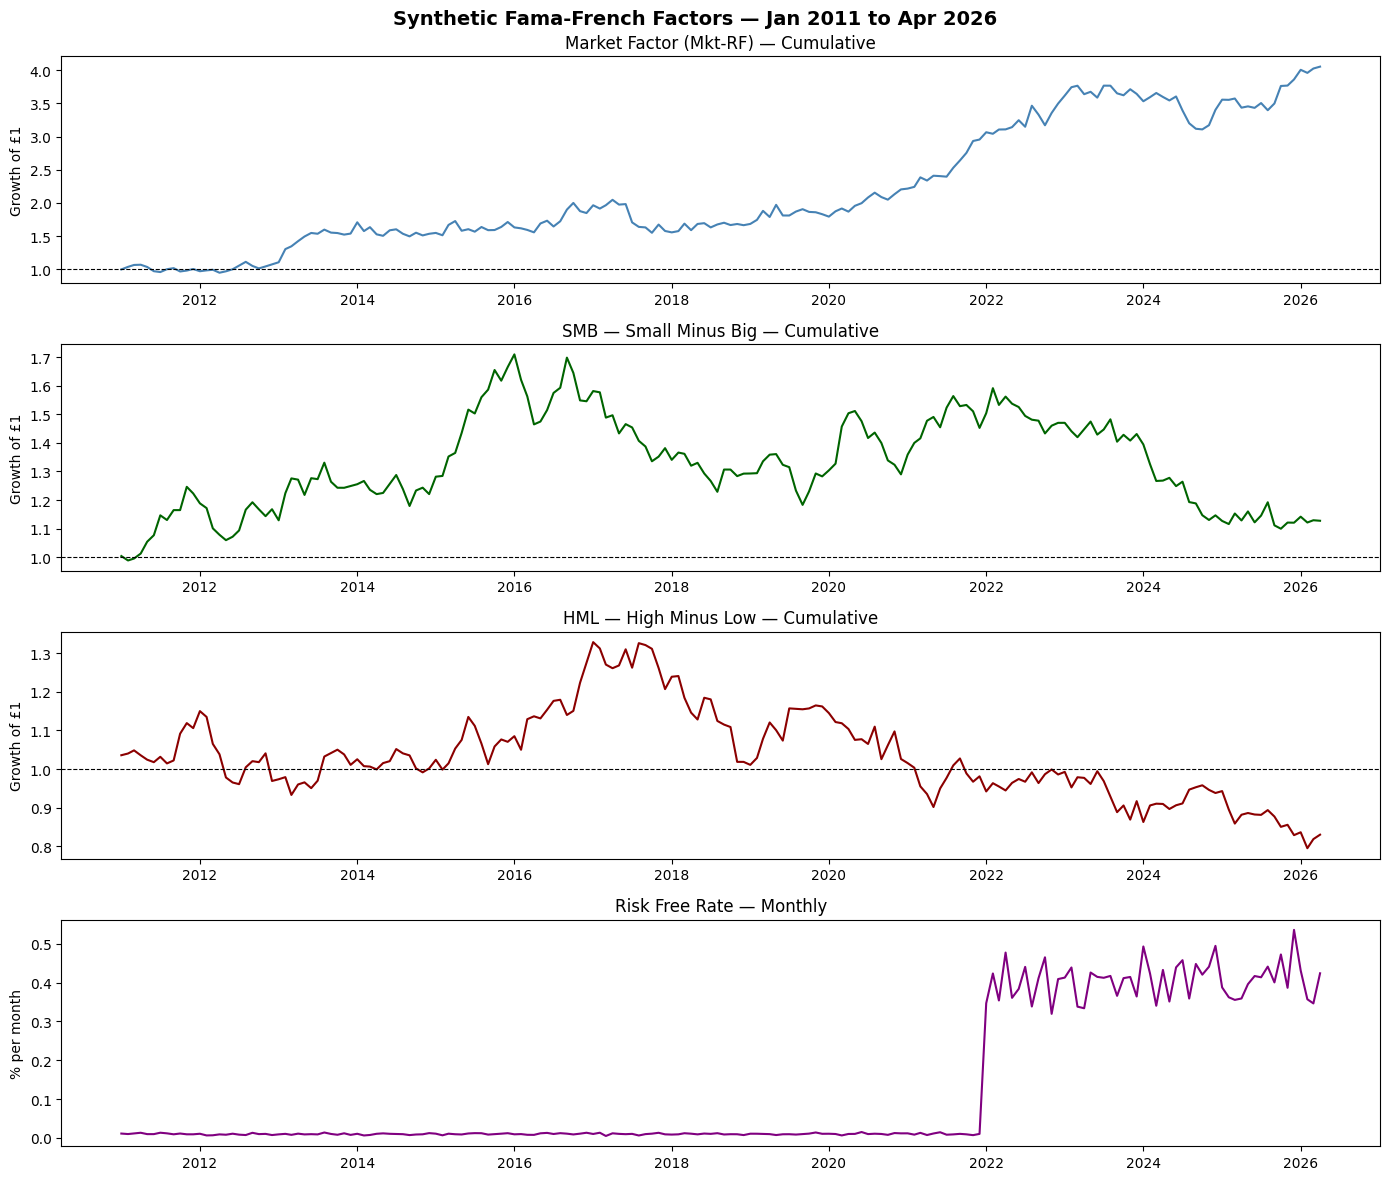

Key statistics:
  Market annualised return: 10.2%
  SMB annualised return:    1.4%
  HML annualised return:    -0.7%
  RF regime change visible: 0.007% → 0.424%


In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle("Synthetic Fama-French Factors — Jan 2011 to Apr 2026", 
             fontsize=14, fontweight='bold')

factors_pd = factors.to_pandas()

# Cumulative returns — more intuitive than monthly
cum_mkt = (1 + factors_pd["mkt_rf"] / 100).cumprod()
cum_smb = (1 + factors_pd["smb"] / 100).cumprod()
cum_hml = (1 + factors_pd["hml"] / 100).cumprod()

axes[0].plot(factors_pd["date"], cum_mkt, color="steelblue", linewidth=1.5)
axes[0].set_title("Market Factor (Mkt-RF) — Cumulative")
axes[0].axhline(y=1, color="black", linestyle="--", linewidth=0.8)
axes[0].set_ylabel("Growth of £1")

axes[1].plot(factors_pd["date"], cum_smb, color="darkgreen", linewidth=1.5)
axes[1].set_title("SMB — Small Minus Big — Cumulative")
axes[1].axhline(y=1, color="black", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("Growth of £1")

axes[2].plot(factors_pd["date"], cum_hml, color="darkred", linewidth=1.5)
axes[2].set_title("HML — High Minus Low — Cumulative")
axes[2].axhline(y=1, color="black", linestyle="--", linewidth=0.8)
axes[2].set_ylabel("Growth of £1")

axes[3].plot(factors_pd["date"], factors_pd["rf"], color="purple", linewidth=1.5)
axes[3].set_title("Risk Free Rate — Monthly")
axes[3].set_ylabel("% per month")

plt.tight_layout()
plt.show()

print("Key statistics:")
print(f"  Market annualised return: {factors_pd['mkt_rf'].mean() * 12:.1f}%")
print(f"  SMB annualised return:    {factors_pd['smb'].mean() * 12:.1f}%")
print(f"  HML annualised return:    {factors_pd['hml'].mean() * 12:.1f}%")
print(f"  RF regime change visible: {factors_pd['rf'].iloc[130]:.3f}% → {factors_pd['rf'].iloc[133]:.3f}%")

In [4]:
# ── Known parameters — we plant these, regression should recover them ──
ALPHA_MONTHLY = 0.30      # +0.30% per month = +3.6% annualised genuine alpha
BETA_MKT      = 1.0       # moves 1-for-1 with market
BETA_SMB      = -0.10     # slight large-cap tilt — expected for S&P 500 universe
BETA_HML      = -0.20     # slight growth tilt — expected for momentum strategy
NOISE_STD     = 3.0       # idiosyncratic volatility — returns factors don't explain

print("Planted parameters:")
print(f"  Alpha:    {ALPHA_MONTHLY}% per month ({ALPHA_MONTHLY * 12:.1f}% annualised)")
print(f"  β_mkt:    {BETA_MKT}")
print(f"  β_smb:    {BETA_SMB}")
print(f"  β_hml:    {BETA_HML}")
print(f"  Noise σ:  {NOISE_STD}% per month")
print()

# ── Construct portfolio excess return from known parameters ────────────
noise = np.random.normal(0, NOISE_STD, n_months)

portfolio_excess = (
    ALPHA_MONTHLY
    + BETA_MKT * factors["mkt_rf"].to_numpy()
    + BETA_SMB * factors["smb"].to_numpy()
    + BETA_HML * factors["hml"].to_numpy()
    + noise
)

# ── Portfolio total return = excess return + risk free rate ────────────
portfolio_return = portfolio_excess + factors["rf"].to_numpy()

# ── Add to factors DataFrame ───────────────────────────────────────────
portfolio = factors.with_columns([
    pl.Series("portfolio_excess", portfolio_excess),
    pl.Series("portfolio_return", portfolio_return),
])

print(f"Portfolio constructed — {len(portfolio)} months")
print(f"Mean monthly excess return: {portfolio_excess.mean():.3f}%")
print(f"Mean monthly total return:  {portfolio_return.mean():.3f}%")
print(f"Annualised excess return:   {portfolio_excess.mean() * 12:.1f}%")
print(f"Std dev monthly:            {portfolio_excess.std():.2f}%")
print(f"Sharpe (monthly):           {portfolio_excess.mean() / portfolio_excess.std():.3f}")

Planted parameters:
  Alpha:    0.3% per month (3.6% annualised)
  β_mkt:    1.0
  β_smb:    -0.1
  β_hml:    -0.2
  Noise σ:  3.0% per month

Portfolio constructed — 184 months
Mean monthly excess return: 1.699%
Mean monthly total return:  1.820%
Annualised excess return:   20.4%
Std dev monthly:            5.31%
Sharpe (monthly):           0.320


In [5]:
# ── Prepare regression inputs ──────────────────────────────────────────
X = portfolio.select(["mkt_rf", "smb", "hml"]).to_numpy()
y = portfolio["portfolio_excess"].to_numpy()

# Add constant for intercept — this is the alpha
X_with_const = sm.add_constant(X)

# ── Run OLS regression ─────────────────────────────────────────────────
model  = sm.OLS(y, X_with_const)
result = model.fit()

# ── Extract key outputs ────────────────────────────────────────────────
alpha_monthly    = result.params[0]
alpha_annualised = alpha_monthly * 12
alpha_tstat      = result.tvalues[0]
beta_mkt         = result.params[1]
beta_smb         = result.params[2]
beta_hml         = result.params[3]
r_squared        = result.rsquared

print("=" * 55)
print("SPANNING TEST RESULTS — SYNTHETIC PORTFOLIO")
print("=" * 55)
print()
print("── Alpha ──────────────────────────────────────────")
print(f"  Monthly alpha:      {alpha_monthly:.4f}%")
print(f"  Annualised alpha:   {alpha_annualised:.2f}%")
print(f"  T-statistic:        {alpha_tstat:.3f}")
print(f"  Significant?        {'YES' if abs(alpha_tstat) > 2.0 else 'NO'}")
print()
print("── Factor loadings ────────────────────────────────")
print(f"  β_mkt:   {beta_mkt:.4f}  (planted: {BETA_MKT})")
print(f"  β_smb:   {beta_smb:.4f}  (planted: {BETA_SMB})")
print(f"  β_hml:   {beta_hml:.4f}  (planted: {BETA_HML})")
print()
print("── Model fit ──────────────────────────────────────")
print(f"  R-squared:  {r_squared:.4f}")
print(f"  N months:   {len(y)}")
print()
print("── Planted vs Recovered ───────────────────────────")
print(f"  Alpha:   planted {ALPHA_MONTHLY:.3f}%  →  recovered {alpha_monthly:.3f}%")
print(f"  β_mkt:   planted {BETA_MKT:.3f}     →  recovered {beta_mkt:.3f}")
print(f"  β_smb:   planted {BETA_SMB:.3f}    →  recovered {beta_smb:.3f}")
print(f"  β_hml:   planted {BETA_HML:.3f}    →  recovered {beta_hml:.3f}")

SPANNING TEST RESULTS — SYNTHETIC PORTFOLIO

── Alpha ──────────────────────────────────────────
  Monthly alpha:      0.7876%
  Annualised alpha:   9.45%
  T-statistic:        3.730
  Significant?        YES

── Factor loadings ────────────────────────────────
  β_mkt:   1.0700  (planted: 1.0)
  β_smb:   -0.0694  (planted: -0.1)
  β_hml:   -0.1301  (planted: -0.2)

── Model fit ──────────────────────────────────────
  R-squared:  0.7267
  N months:   184

── Planted vs Recovered ───────────────────────────
  Alpha:   planted 0.300%  →  recovered 0.788%
  β_mkt:   planted 1.000     →  recovered 1.070
  β_smb:   planted -0.100    →  recovered -0.069
  β_hml:   planted -0.200    →  recovered -0.130


In [6]:
portfolio_excess = (
    ALPHA_MONTHLY
    + BETA_MKT * factors["mkt_rf"].to_numpy()
    + BETA_SMB * factors["smb"].to_numpy()
    + BETA_HML * factors["hml"].to_numpy()
    + noise
)

In [7]:
print(f"Actual noise mean: {noise.mean():.4f}%")
print(f"Expected noise mean: 0.0000%")
print(f"Difference absorbed into alpha: {noise.mean():.4f}%")
print(f"Planted alpha + noise mean: {ALPHA_MONTHLY + noise.mean():.4f}%")

Actual noise mean: 0.5469%
Expected noise mean: 0.0000%
Difference absorbed into alpha: 0.5469%
Planted alpha + noise mean: 0.8469%


In [10]:
def run_spanning_test(portfolio_excess, factors, label):
    """Helper — runs regression and prints clean summary."""
    X = factors.select(["mkt_rf", "smb", "hml"]).to_numpy()
    X_with_const = sm.add_constant(X)
    result = sm.OLS(portfolio_excess, X_with_const).fit()
    
    alpha_m = result.params[0]
    tstat   = result.tvalues[0]
    r2      = result.rsquared
    
    print(f"\n{label}")
    print(f"  Alpha:       {alpha_m:.3f}% /month ({alpha_m*12:.1f}% annualised)")
    print(f"  T-statistic: {tstat:.3f}  {'✓ SIGNIFICANT' if abs(tstat) > 2.0 else '✗ NOT SIGNIFICANT'}")
    print(f"  R-squared:   {r2:.3f}")
    return result

np.random.seed(42)
base_noise = np.random.normal(0, NOISE_STD, n_months)
base_excess = (ALPHA_MONTHLY 
               + BETA_MKT * factors["mkt_rf"].to_numpy()
               + BETA_SMB * factors["smb"].to_numpy()
               + BETA_HML * factors["hml"].to_numpy()
               + base_noise)

# ── Experiment 1 — Remove alpha entirely ──────────────────────────────
no_alpha_excess = (0.0
                   + BETA_MKT * factors["mkt_rf"].to_numpy()
                   + BETA_SMB * factors["smb"].to_numpy()
                   + BETA_HML * factors["hml"].to_numpy()
                   + base_noise)

# ── Experiment 2 — Change HML loading to positive ─────────────────────
value_tilt_excess = (ALPHA_MONTHLY
                     + BETA_MKT * factors["mkt_rf"].to_numpy()
                     + 0.3 * factors["smb"].to_numpy()
                     + 0.3 * factors["hml"].to_numpy()
                     + base_noise)

# ── Experiment 3 — Double the noise ───────────────────────────────────
np.random.seed(99)
high_noise_clean = np.random.normal(0, NOISE_STD * 2, n_months)
noisy_excess = (ALPHA_MONTHLY
                + BETA_MKT * factors["mkt_rf"].to_numpy()
                + BETA_SMB * factors["smb"].to_numpy()
                + BETA_HML * factors["hml"].to_numpy()
                + high_noise_clean)

# ── Experiment 4 — Reduce sample to 60 months ─────────────────────────
short_excess  = base_excess[:60]
short_factors = factors[:60]

print("=" * 55)
print("STRESS TESTS — SYNTHETIC PORTFOLIO")
print("=" * 55)

run_spanning_test(base_excess,       factors,       "Base case (alpha=0.30%, noise σ=3%)")
run_spanning_test(no_alpha_excess,   factors,       "Experiment 1 — Zero alpha")
run_spanning_test(value_tilt_excess, factors,       "Experiment 2 — Value tilt (HML=+0.3)")
run_spanning_test(noisy_excess,      factors,       "Experiment 3 — Double noise (σ=6%)")
run_spanning_test(short_excess,      short_factors, "Experiment 4 — 60 months only")

STRESS TESTS — SYNTHETIC PORTFOLIO

Base case (alpha=0.30%, noise σ=3%)
  Alpha:       0.190% /month (2.3% annualised)
  T-statistic: 0.889  ✗ NOT SIGNIFICANT
  R-squared:   0.709

Experiment 1 — Zero alpha
  Alpha:       -0.110% /month (-1.3% annualised)
  T-statistic: -0.512  ✗ NOT SIGNIFICANT
  R-squared:   0.709

Experiment 2 — Value tilt (HML=+0.3)
  Alpha:       0.190% /month (2.3% annualised)
  T-statistic: 0.889  ✗ NOT SIGNIFICANT
  R-squared:   0.746

Experiment 3 — Double noise (σ=6%)
  Alpha:       0.599% /month (7.2% annualised)
  T-statistic: 1.314  ✗ NOT SIGNIFICANT
  R-squared:   0.329

Experiment 4 — 60 months only
  Alpha:       -0.334% /month (-4.0% annualised)
  T-statistic: -0.979  ✗ NOT SIGNIFICANT
  R-squared:   0.790


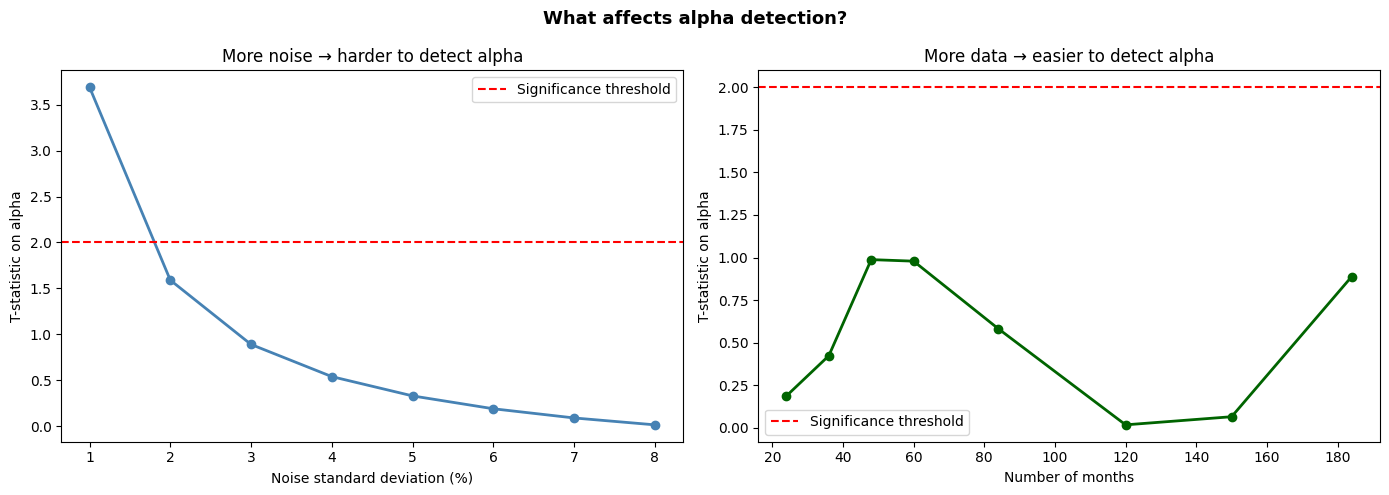

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("What affects alpha detection?", fontsize=13, fontweight='bold')

# Left panel — noise level vs t-statistic
noise_levels = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
tstats = []

for noise_std in noise_levels:
    np.random.seed(42)
    n = np.random.normal(0, noise_std, n_months)
    pe = (ALPHA_MONTHLY
          + BETA_MKT * factors["mkt_rf"].to_numpy()
          + BETA_SMB * factors["smb"].to_numpy()
          + BETA_HML * factors["hml"].to_numpy()
          + n)
    X = sm.add_constant(factors.select(["mkt_rf", "smb", "hml"]).to_numpy())
    r = sm.OLS(pe, X).fit()
    tstats.append(abs(r.tvalues[0]))

axes[0].plot(noise_levels, tstats, color="steelblue", linewidth=2, marker="o")
axes[0].axhline(y=2.0, color="red", linestyle="--", linewidth=1.5, label="Significance threshold")
axes[0].set_xlabel("Noise standard deviation (%)")
axes[0].set_ylabel("T-statistic on alpha")
axes[0].set_title("More noise → harder to detect alpha")
axes[0].legend()

# Right panel — sample size vs t-statistic
sample_sizes = [24, 36, 48, 60, 84, 120, 150, 184]
tstats_n = []

sample_sizes = [24, 36, 48, 60, 84, 120, 150, 184]
tstats_n = []

for n_obs in sample_sizes:
    np.random.seed(42)  # reset inside loop — same noise pattern, different length
    n = np.random.normal(0, NOISE_STD, n_obs)
    f_sub = factors[:n_obs]
    pe = (ALPHA_MONTHLY
          + BETA_MKT * f_sub["mkt_rf"].to_numpy()
          + BETA_SMB * f_sub["smb"].to_numpy()
          + BETA_HML * f_sub["hml"].to_numpy()
          + n)
    X = sm.add_constant(f_sub.select(["mkt_rf", "smb", "hml"]).to_numpy())
    r = sm.OLS(pe, X).fit()
    tstats_n.append(abs(r.tvalues[0]))

axes[1].plot(sample_sizes, tstats_n, color="darkgreen", linewidth=2, marker="o")
axes[1].axhline(y=2.0, color="red", linestyle="--", linewidth=1.5, label="Significance threshold")
axes[1].set_xlabel("Number of months")
axes[1].set_ylabel("T-statistic on alpha")
axes[1].set_title("More data → easier to detect alpha")
axes[1].legend()

plt.tight_layout()
plt.show()